# Feature Engineering EDA

This notebook compares raw toilet logs and engineered feature distributions for reporting.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
db_path = os.path.abspath(os.path.join('..', 'hospital_iot.db'))
print(f'DB path: {db_path}')

conn = sqlite3.connect(db_path)

raw_df = pd.read_sql_query('SELECT * FROM Toilet_Logs', conn)
feat_df = pd.read_sql_query('SELECT * FROM Toilet_Log_Features', conn)
tod_df = pd.read_sql_query('SELECT * FROM TimeOfDay', conn)

conn.close()

print('Raw rows:', len(raw_df))
print('Feature rows:', len(feat_df))
print('Raw columns:', list(raw_df.columns))
print('Feature columns:', list(feat_df.columns))

DB path: c:\Users\c0077\OneDrive - The Hong Kong Polytechnic University\Documents\study\FYP\Code\Backend\hospital_iot.db
Raw rows: 18484
Feature rows: 18382
Raw columns: ['log_id', 'patient_id', 'entry_time', 'exit_time', 'duration_seconds', 'time_of_day_id', 'is_accident', 'created_at', 'updated_at']
Feature columns: ['feature_id', 'log_id', 'patient_id', 'duration_seconds', 'time_of_day_id', 'hour_of_day', 'day_of_week', 'is_weekend', 'time_since_last_log_minutes', 'is_accident', 'mean_duration_7d', 'max_duration_7d', 'min_duration_7d', 'std_duration_7d', 'log_count_7d', 'tod_deep_night_count_7d', 'tod_early_morning_count_7d', 'tod_late_morning_count_7d', 'tod_afternoon_count_7d', 'tod_evening_count_7d', 'accident_ratio_7d', 'age_x_mobility', 'gastro_x_duration', 'age', 'gender', 'mobility_level', 'has_gastro_issue', 'has_uro_issue', 'self_reported_max_seconds', 'report_minus_duration', 'duration_to_report_ratio', 'created_at']


In [3]:
raw_df['entry_time'] = pd.to_datetime(raw_df['entry_time'], errors='coerce')
raw_df['exit_time'] = pd.to_datetime(raw_df['exit_time'], errors='coerce')

print('Raw null counts:')
print(raw_df.isnull().sum().sort_values(ascending=False).head(10))

print('Feature null counts:')
print(feat_df.isnull().sum().sort_values(ascending=False).head(10))

Raw null counts:
log_id              0
patient_id          0
entry_time          0
exit_time           0
duration_seconds    0
time_of_day_id      0
is_accident         0
created_at          0
updated_at          0
dtype: int64
Feature null counts:
feature_id                     0
log_id                         0
patient_id                     0
duration_seconds               0
time_of_day_id                 0
hour_of_day                    0
day_of_week                    0
is_weekend                     0
time_since_last_log_minutes    0
is_accident                    0
dtype: int64


Duration summary (raw):
count    18484.000000
mean       921.278187
std        887.467053
min        317.000000
25%        613.000000
50%        759.000000
75%        951.000000
max      14299.000000
Name: duration_seconds, dtype: float64


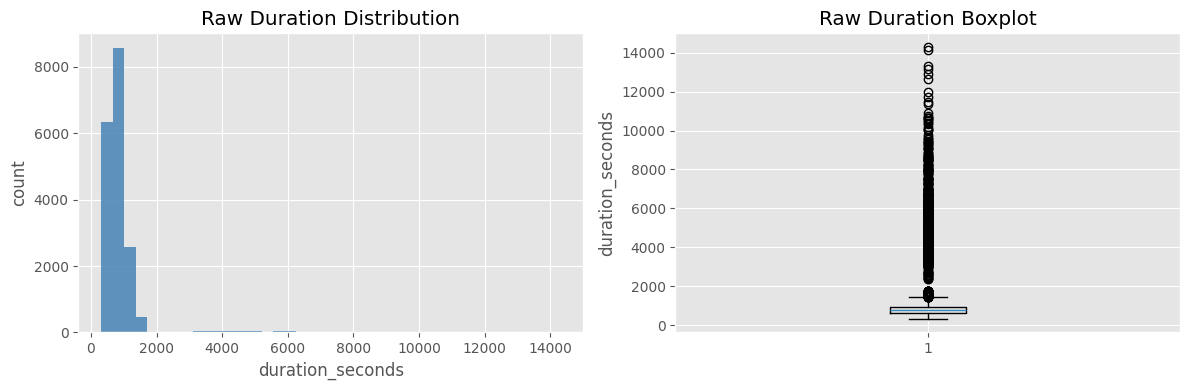

In [4]:
print('Duration summary (raw):')
print(raw_df['duration_seconds'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw_df['duration_seconds'].dropna(), bins=40, color='steelblue', alpha=0.85)
axes[0].set_title('Raw Duration Distribution')
axes[0].set_xlabel('duration_seconds')
axes[0].set_ylabel('count')

axes[1].boxplot(raw_df['duration_seconds'].dropna(), vert=True)
axes[1].set_title('Raw Duration Boxplot')
axes[1].set_ylabel('duration_seconds')

plt.tight_layout()
plt.show()

Feature summary:
       mean_duration_7d  std_duration_7d  time_since_last_log_minutes  \
count      18382.000000     18382.000000                 18382.000000   
mean         916.545505       647.255619                   232.089000   
std          287.909177       507.345005                   236.968441   
min          443.000000         0.000000                     0.000000   
25%          694.485862       125.352002                    59.000000   
50%          868.309524       625.210922                   152.000000   
75%         1064.089706       974.781706                   326.000000   
max         7533.000000      4255.000000                  1709.000000   

       accident_ratio_7d  log_count_7d  report_minus_duration  \
count       18382.000000  18382.000000           18382.000000   
mean            0.025937     37.998858            1058.688500   
std             0.028103     11.227800             913.811782   
min             0.000000      1.000000          -10639.000000   


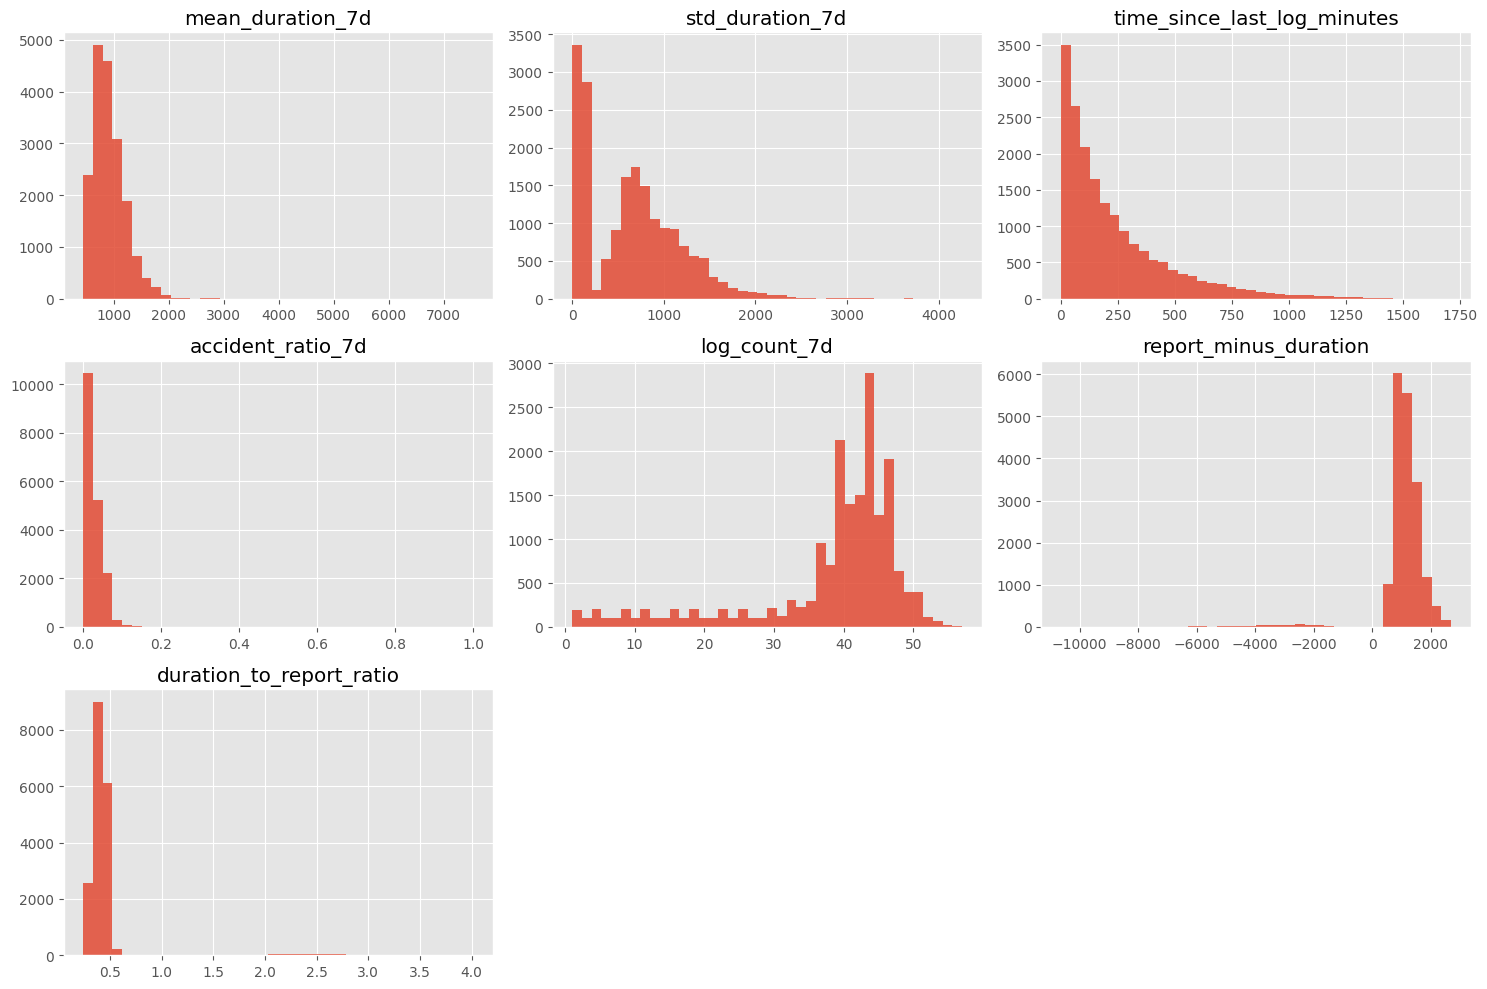

In [5]:
feature_cols = [
    'mean_duration_7d',
    'std_duration_7d',
    'time_since_last_log_minutes',
    'accident_ratio_7d',
    'log_count_7d',
    'report_minus_duration',
    'duration_to_report_ratio',
]

print('Feature summary:')
print(feat_df[feature_cols].describe())

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(feat_df[col].dropna(), bins=40, alpha=0.85)
    axes[i].set_title(col)

for i in range(len(feature_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

                raw_count  feature_count
time_of_day_id                          
Early Morning        5370           5333
Afternoon            3854           3854
Late Morning         3576           3576
Evening              2897           2897
Deep Night           2787           2722


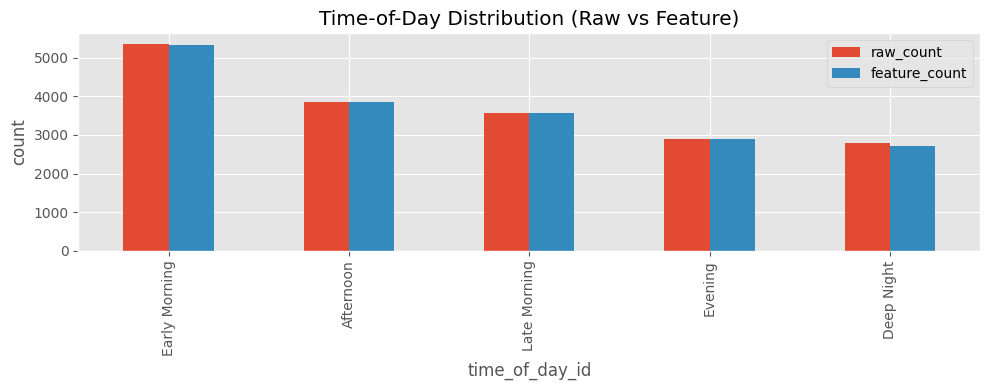

In [6]:
tod_map = dict(zip(tod_df['id'], tod_df['label']))

raw_tod_counts = raw_df['time_of_day_id'].map(tod_map).value_counts()
feat_tod_counts = feat_df['time_of_day_id'].map(tod_map).value_counts()

compare_tod = pd.DataFrame({
    'raw_count': raw_tod_counts,
    'feature_count': feat_tod_counts
}).fillna(0).astype(int)

print(compare_tod)
compare_tod.plot(kind='bar', figsize=(10, 4), title='Time-of-Day Distribution (Raw vs Feature)')
plt.ylabel('count')
plt.tight_layout()
plt.show()

Patient-level mean_duration_7d summary:
count     100.000000
mean      917.262650
std       251.859734
min       552.380522
25%       717.987077
50%       881.032346
75%      1059.216977
max      1640.116015
Name: mean_duration_7d, dtype: float64


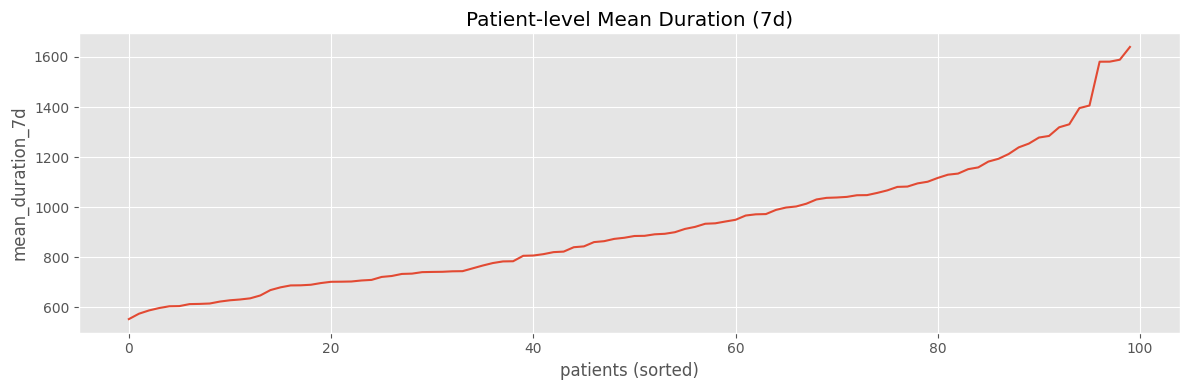

In [7]:
patient_mean = feat_df.groupby('patient_id')['mean_duration_7d'].mean().sort_values()

print('Patient-level mean_duration_7d summary:')
print(patient_mean.describe())

plt.figure(figsize=(12, 4))
plt.plot(patient_mean.values)
plt.title('Patient-level Mean Duration (7d)')
plt.xlabel('patients (sorted)')
plt.ylabel('mean_duration_7d')
plt.tight_layout()
plt.show()

In [8]:
raw_n = len(raw_df)
feat_n = len(feat_df)
dropped = raw_n - feat_n
drop_ratio = dropped / raw_n if raw_n > 0 else np.nan

print(f'Raw rows: {raw_n}')
print(f'Feature rows: {feat_n}')
print(f'Dropped cold-start rows: {dropped}')
print(f'Drop ratio: {drop_ratio:.4f}')

Raw rows: 18484
Feature rows: 18382
Dropped cold-start rows: 102
Drop ratio: 0.0055


In [9]:
print('Raw table columns (before feature engineering):')
print(f'Total columns: {len(raw_df.columns)}')
for i, c in enumerate(raw_df.columns, 1):
    print(f'{i:02d}. {c}')

Raw table columns (before feature engineering):
Total columns: 9
01. log_id
02. patient_id
03. entry_time
04. exit_time
05. duration_seconds
06. time_of_day_id
07. is_accident
08. created_at
09. updated_at


In [10]:
print('Feature table columns (after feature engineering):')
print(f'Total columns: {len(feat_df.columns)}')
for i, c in enumerate(feat_df.columns, 1):
    print(f'{i:02d}. {c}')

Feature table columns (after feature engineering):
Total columns: 32
01. feature_id
02. log_id
03. patient_id
04. duration_seconds
05. time_of_day_id
06. hour_of_day
07. day_of_week
08. is_weekend
09. time_since_last_log_minutes
10. is_accident
11. mean_duration_7d
12. max_duration_7d
13. min_duration_7d
14. std_duration_7d
15. log_count_7d
16. tod_deep_night_count_7d
17. tod_early_morning_count_7d
18. tod_late_morning_count_7d
19. tod_afternoon_count_7d
20. tod_evening_count_7d
21. accident_ratio_7d
22. age_x_mobility
23. gastro_x_duration
24. age
25. gender
26. mobility_level
27. has_gastro_issue
28. has_uro_issue
29. self_reported_max_seconds
30. report_minus_duration
31. duration_to_report_ratio
32. created_at


Feature-to-label relation (Pearson correlation):
                    feature  pearson_corr_with_is_accident  abs_corr
   duration_to_report_ratio                       0.959420  0.959420
           duration_seconds                       0.882551  0.882551
      report_minus_duration                      -0.857711  0.857711
          gastro_x_duration                       0.254362  0.254362
          accident_ratio_7d                      -0.031055  0.031055
            std_duration_7d                      -0.027575  0.027575
             time_of_day_id                       0.022898  0.022898
            max_duration_7d                      -0.021844  0.021844
                hour_of_day                       0.021384  0.021384
           mean_duration_7d                      -0.015192  0.015192
 tod_early_morning_count_7d                       0.013587  0.013587
  tod_late_morning_count_7d                       0.010749  0.010749
               log_count_7d                       0.01

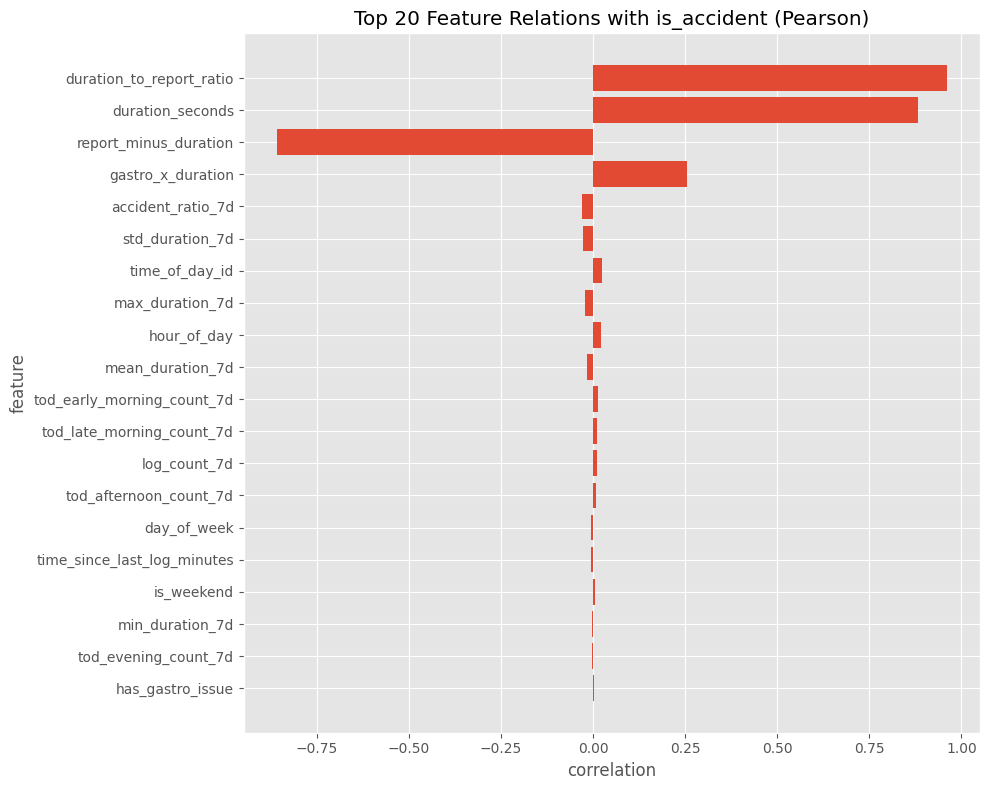

In [11]:
label_col = 'is_accident'

if label_col not in feat_df.columns:
    raise ValueError(f"Label column '{label_col}' not found in feat_df")

# Pearson correlation is used as the relation metric.
# For binary label (0/1), this is equivalent to point-biserial correlation.
work_df = feat_df.copy()

exclude_cols = {'feature_id', 'log_id', 'patient_id', 'created_at'}
candidate_cols = [c for c in work_df.columns if c not in exclude_cols]

# One-hot encode categorical columns so every feature is numeric
X = pd.get_dummies(work_df[candidate_cols], drop_first=False)
X[label_col] = pd.to_numeric(work_df[label_col], errors='coerce')

# If label has only one class, Pearson correlation is mathematically undefined.
# In that case, return 0.0 to avoid NaN outputs in reporting tables.
y = X[label_col]
if y.nunique(dropna=True) < 2:
    print(f"Warning: '{label_col}' has only one class in current data. Pearson correlation is undefined.")
    print("Setting all feature relations to 0.0 for stable output.")
    corr_series = pd.Series(0.0, index=[c for c in X.columns if c != label_col])
else:
    corr_series = X.corr(numeric_only=True)[label_col].drop(labels=[label_col], errors='ignore')
    corr_series = corr_series.fillna(0.0)

result = pd.DataFrame({
    'feature': corr_series.index,
    'pearson_corr_with_is_accident': corr_series.values,
    'abs_corr': np.abs(corr_series.values)
}).sort_values('abs_corr', ascending=False)

print('Feature-to-label relation (Pearson correlation):')
print(result.head(30).to_string(index=False))

plt.figure(figsize=(10, 8))
plot_df = result.head(20).iloc[::-1]
plt.barh(plot_df['feature'], plot_df['pearson_corr_with_is_accident'])
plt.title('Top 20 Feature Relations with is_accident (Pearson)')
plt.xlabel('correlation')
plt.ylabel('feature')
plt.tight_layout()
plt.show()

## Accident Classification Preprocessing
Prepare features for classification with one-hot encoding (categorical) and standardization (numerical).

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

label_col = 'is_accident'
drop_cols = {'feature_id', 'log_id', 'patient_id', 'created_at', label_col}

model_df = feat_df.sort_values('log_id').reset_index(drop=True).copy()
all_feature_cols = [c for c in model_df.columns if c not in drop_cols]

X = model_df[all_feature_cols]
y = pd.to_numeric(model_df[label_col], errors='coerce').fillna(0).astype(int)

# Explicitly define categorical columns.
# These are non-ordinal or nominal despite being stored as integers.
categorical_cols = [
    'time_of_day_id',   # time-period label (1=deep night ... 5=evening), no linear order
    'day_of_week',      # 0-6, cyclic / nominal
    'is_weekend',       # binary flag
    'mobility_level',   # ordinal category, not a continuous quantity
    'has_gastro_issue', # binary flag (0/1)
    'has_uro_issue',    # binary flag (0/1)
    'gender',           # string category
]
# Keep only those that actually exist in X (guards against future schema changes)
categorical_cols = [c for c in categorical_cols if c in X.columns]
numerical_cols = [c for c in X.columns if c not in categorical_cols]

split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            numerical_cols,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
            ]),
            categorical_cols,
        ),
    ],
    remainder='drop',
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('Accident classification preprocessing done.')
print(f'Train rows: {len(X_train)}  |  Test rows: {len(X_test)}')
print(f'\nNumerical cols ({len(numerical_cols)}) -- standardized:')
for c in numerical_cols:
    print(f'  {c}')
print(f'\nCategorical cols ({len(categorical_cols)}) -- one-hot:')
for c in categorical_cols:
    print(f'  {c}')
print(f'\ny_train class distribution:')
print(y_train.value_counts(normalize=True).rename('ratio'))
print(f'\nProcessed train shape: {X_train_processed.shape}')
print(f'Processed test shape:  {X_test_processed.shape}')

Accident classification preprocessing done.
Train rows: 14705  |  Test rows: 3677

Numerical cols (20) -- standardized:
  duration_seconds
  hour_of_day
  time_since_last_log_minutes
  mean_duration_7d
  max_duration_7d
  min_duration_7d
  std_duration_7d
  log_count_7d
  tod_deep_night_count_7d
  tod_early_morning_count_7d
  tod_late_morning_count_7d
  tod_afternoon_count_7d
  tod_evening_count_7d
  accident_ratio_7d
  age_x_mobility
  gastro_x_duration
  age
  self_reported_max_seconds
  report_minus_duration
  duration_to_report_ratio

Categorical cols (7) -- one-hot:
  time_of_day_id
  day_of_week
  is_weekend
  mobility_level
  has_gastro_issue
  has_uro_issue
  gender

y_train class distribution:
is_accident
0    1.0
Name: ratio, dtype: float64

Processed train shape: (14705, 43)
Processed test shape:  (3677, 43)


In [13]:
# Inspect columns after preprocessing (one-hot + scaling)
processed_feature_names = preprocessor.get_feature_names_out()
processed_feature_names = pd.Index(processed_feature_names).astype(str)

print('Processed feature count:', len(processed_feature_names))
print('First 40 processed feature names:')
for i, name in enumerate(processed_feature_names[:40], 1):
    print(f'{i:02d}. {name}')

processed_train_df = pd.DataFrame(
    X_train_processed.toarray() if hasattr(X_train_processed, 'toarray') else X_train_processed,
    columns=processed_feature_names,
    index=X_train.index,
 )

print('\nProcessed train preview (first 3 rows, first 12 cols):')
display(processed_train_df.iloc[:3, :12])

Processed feature count: 43
First 40 processed feature names:
01. num__duration_seconds
02. num__hour_of_day
03. num__time_since_last_log_minutes
04. num__mean_duration_7d
05. num__max_duration_7d
06. num__min_duration_7d
07. num__std_duration_7d
08. num__log_count_7d
09. num__tod_deep_night_count_7d
10. num__tod_early_morning_count_7d
11. num__tod_late_morning_count_7d
12. num__tod_afternoon_count_7d
13. num__tod_evening_count_7d
14. num__accident_ratio_7d
15. num__age_x_mobility
16. num__gastro_x_duration
17. num__age
18. num__self_reported_max_seconds
19. num__report_minus_duration
20. num__duration_to_report_ratio
21. cat__time_of_day_id_1
22. cat__time_of_day_id_2
23. cat__time_of_day_id_3
24. cat__time_of_day_id_4
25. cat__time_of_day_id_5
26. cat__day_of_week_0
27. cat__day_of_week_1
28. cat__day_of_week_2
29. cat__day_of_week_3
30. cat__day_of_week_4
31. cat__day_of_week_5
32. cat__day_of_week_6
33. cat__is_weekend_0
34. cat__is_weekend_1
35. cat__mobility_level_0
36. cat__mobi

,num__duration_seconds,num__hour_of_day,num__time_since_last_log_minutes,num__mean_duration_7d,num__max_duration_7d,num__min_duration_7d,num__std_duration_7d,num__log_count_7d,num__tod_deep_night_count_7d,num__tod_early_morning_count_7d,num__tod_late_morning_count_7d,num__tod_afternoon_count_7d
0,-0.179310,0.420547,-0.595070,-1.331366,-1.207406,-0.880618,-1.103667,-2.732701,-1.686937,-2.189158,-1.549283,-2.08496
1,-1.504198,0.073980,-0.675398,-1.220041,-1.207406,-0.525145,-1.147978,-2.815544,-1.686937,-2.189158,-1.850942,-2.08496
2,-0.841754,-0.619154,0.698636,-1.096727,-1.207406,0.027206,-1.236943,-2.981231,-1.686937,-2.412514,-2.152601,-2.08496


In [14]:
# Show all processed column names (full list)
all_processed_cols_df = pd.DataFrame({
    'idx': np.arange(1, len(processed_feature_names) + 1),
    'column_name': processed_feature_names
})

pd.set_option('display.max_rows', None)
print('All processed columns:')
print(all_processed_cols_df.to_string(index=False))

print('\nAs python list:')
print(processed_feature_names.tolist())

All processed columns:
 idx                      column_name
   1            num__duration_seconds
   2                 num__hour_of_day
   3 num__time_since_last_log_minutes
   4            num__mean_duration_7d
   5             num__max_duration_7d
   6             num__min_duration_7d
   7             num__std_duration_7d
   8                num__log_count_7d
   9     num__tod_deep_night_count_7d
  10  num__tod_early_morning_count_7d
  11   num__tod_late_morning_count_7d
  12      num__tod_afternoon_count_7d
  13        num__tod_evening_count_7d
  14           num__accident_ratio_7d
  15              num__age_x_mobility
  16           num__gastro_x_duration
  17                         num__age
  18   num__self_reported_max_seconds
  19       num__report_minus_duration
  20    num__duration_to_report_ratio
  21            cat__time_of_day_id_1
  22            cat__time_of_day_id_2
  23            cat__time_of_day_id_3
  24            cat__time_of_day_id_4
  25            cat__time_o